[Previous: Architecture 3: Microservices](03_Microservices.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 5: Choosing an Architecture](05_Choosing_an_Architecture.ipynb)

# Architecture 4: Event-Driven and CQRS

**Learning objectives.** After this module you can:

* replace synchronous calls with published events and explain what the producer stops knowing;
* demonstrate eventual consistency and consumer lag with a simulated bus;
* build a CQRS read model from events and say why it is shaped differently from the write model;
* implement a saga with compensating actions for a transaction that spans services.

## 1. Events instead of calls

In Module 3 the order service called billing and shipping and waited. With events, the order service **publishes** "OrderPlaced" and moves on.
Billing and shipping **subscribe** and react when they get to it. The producer does not know who listens, so new consumers (analytics, email) cost nothing to add.

The bus below is a queue in memory. `deliver(k)` hands out at most k events, which lets us make the lag visible.

pending events: 2 | billing has charged: []
after delivery:  billing [1, 2] shipping [1, 2] analytics 2


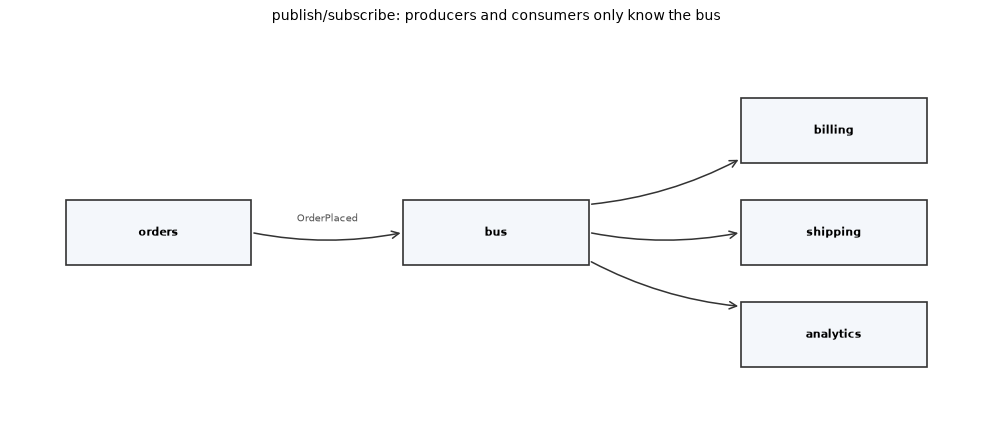

In [1]:
from dplab import component_diagram, EventBus, traced, trace

@traced
class Billing:
    def __init__(self, bus):
        self.charged = []
        bus.subscribe("OrderPlaced", self.on_order)
    def on_order(self, e): self.charged.append(e["id"])

@traced
class Shipping:
    def __init__(self, bus):
        self.shipped = []
        bus.subscribe("OrderPlaced", self.on_order)
    def on_order(self, e): self.shipped.append(e["id"])

@traced
class Analytics:                                   # added later; the order service never changed
    def __init__(self, bus):
        self.count = 0
        bus.subscribe("OrderPlaced", self.on_order)
    def on_order(self, e): self.count += 1

@traced
class Orders:
    def __init__(self, bus): self.bus = bus
    def place(self, order_id, item):
        self.bus.publish("OrderPlaced", {"id": order_id, "item": item})
        return "accepted"                          # returns before anyone reacted

bus = EventBus()
billing, shipping, analytics = Billing(bus), Shipping(bus), Analytics(bus)
orders = Orders(bus)
with trace() as t:
    orders.place(1, "lamp"); orders.place(2, "chair")
    print("pending events:", len(bus.pending), "| billing has charged:", billing.charged)
    bus.deliver(10)
    print("after delivery:  billing", billing.charged, "shipping", shipping.shipped, "analytics", analytics.count)
t.diagram(title="publish returns immediately; consumers run when the bus delivers", max_messages=20)
component_diagram(["orders", "bus", "billing", "shipping", "analytics"],
                  [("orders", "bus", "OrderPlaced"), ("bus", "billing"), ("bus", "shipping"), ("bus", "analytics")],
                  layout={"orders": (0, 1), "bus": (1.4, 1), "billing": (2.8, 0), "shipping": (2.8, 1), "analytics": (2.8, 2)},
                  title="publish/subscribe: producers and consumers only know the bus")

## 2. Eventual consistency

Between `publish` and `deliver` the world is inconsistent: the order exists, the charge does not. In a real system that gap is milliseconds to seconds, and it is
**normal**. Designs that need to read their own writes immediately must either wait for the event, query the write side, or accept a stale answer.

## 3. CQRS: separate models for writing and reading

**Command Query Responsibility Segregation.** The write model validates commands and emits events. One or more **read models** subscribe to those events and keep
data in exactly the shape a screen needs (a dashboard with three counters, a search index, a per-customer history). Reads never join tables; writes never care about screens.

The lab has a write model of orders and a dashboard read model that only counts events. Tick the consumer slowly and watch the dashboard trail the truth.

Event Lab (static preview). Run this cell in JupyterLab for the interactive version.


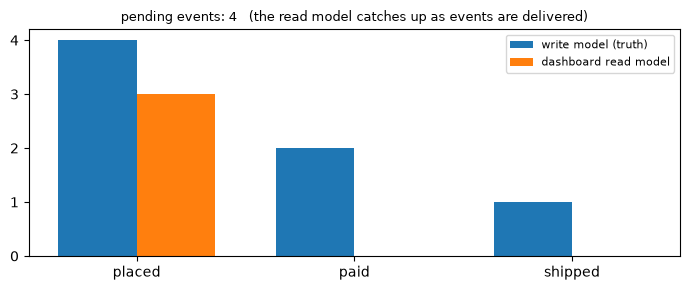

In [2]:
from dplab import event_lab

event_lab()

> **What to notice.** The dashboard never queries the orders table. It could live in another service, on another machine, rebuilt from scratch by replaying every event.
> That replay is the door to event sourcing, where the events *are* the database.

## 4. Sagas: transactions without a transaction

Placing an order must reserve stock and charge the card. In a monolith that is one database transaction. Across services there is no shared transaction, so use a **saga**:
a sequence of local steps, each with a **compensating action** that undoes it if a later step fails.

order 1: confirmed
order 2: cancelled: card declined
stock reserved: [1] | charged: [1]


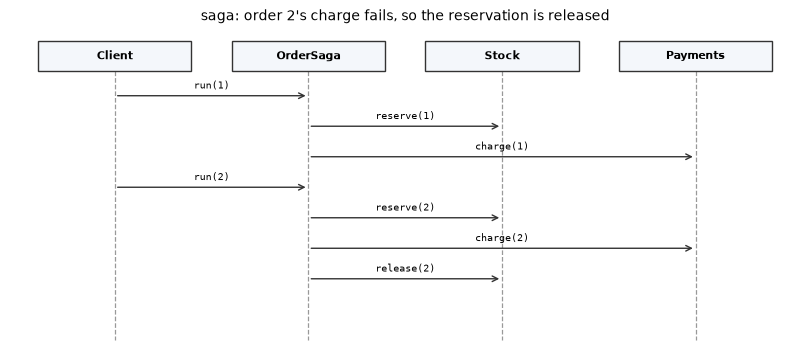

In [3]:
@traced
class Stock:
    def __init__(self): self.reserved = []
    def reserve(self, order_id): self.reserved.append(order_id); return True
    def release(self, order_id): self.reserved.remove(order_id)

@traced
class Payments:
    def __init__(self, fail_for=()): self.charged, self.fail_for = [], set(fail_for)
    def charge(self, order_id):
        if order_id in self.fail_for: raise RuntimeError("card declined")
        self.charged.append(order_id); return True
    def refund(self, order_id): self.charged.remove(order_id)

@traced
class OrderSaga:
    def __init__(self, stock, payments): self.stock, self.payments = stock, payments
    def run(self, order_id):
        done = []                                   # (compensation, args) for every completed step
        try:
            self.stock.reserve(order_id); done.append((self.stock.release, order_id))
            self.payments.charge(order_id); done.append((self.payments.refund, order_id))
            return "confirmed"
        except Exception as e:
            for undo, arg in reversed(done):        # compensate in reverse order
                undo(arg)
            return f"cancelled: {e}"

stock, payments = Stock(), Payments(fail_for={2})
saga = OrderSaga(stock, payments)
with trace() as t:
    print("order 1:", saga.run(1))
    print("order 2:", saga.run(2))
print("stock reserved:", stock.reserved, "| charged:", payments.charged)
t.diagram(title="saga: order 2's charge fails, so the reservation is released", max_messages=20)

> **What to notice.** After order 2 the stock reservation is gone: the compensation ran. Compensations must be idempotent and must not fail, because there is nothing left to undo them.

## Try it yourself

**Exercise 1.** Add an `EmailService` subscriber to Section 1 without touching `Orders`. Then add an "OrderCancelled" event and a consumer for it.

**Exercise 2.** Make `EventBus.deliver` drop an event with 10 percent probability. What does the read model do? Add an event counter so the read model can detect the gap.

**Exercise 3.** Extend the saga with a third step, `Shipping.book`, and a compensation for it. Make the third step fail and confirm both earlier steps are undone in reverse order.

**Exercise 4 (challenge).** Rebuild the dashboard read model from scratch by replaying `bus.delivered`. That is event sourcing in ten lines.

<details><summary>Solutions</summary>

```python
# Exercise 2: the read model silently undercounts. Give each event a sequence number in publish() and let the read model notice a skipped number.

# Exercise 3
class Shipping2:
    def __init__(self): self.booked = []
    def book(self, oid): raise RuntimeError("no courier")
    def cancel(self, oid): self.booked.remove(oid)
# add: self.shipping.book(order_id); done.append((self.shipping.cancel, order_id)) after the charge.

# Exercise 4
def rebuild(delivered):
    placed = paid = 0
    for topic, payload in delivered:
        placed += topic == "OrderPlaced"; paid += topic == "OrderPaid"
    return placed, paid
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [4]:
from dplab import quiz

quiz('arch4')

Checkpoint quiz, Architecture 4 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. In publish/subscribe the publisher
    a) waits for each subscriber
    b) does not know who consumes the event
    c) calls subscribers directly
    d) must be a database

Q2. Eventual consistency means
    a) data is never consistent
    b) read models lag behind writes for a short time before catching up
    c) writes are lost
    d) reads are slow

Q3. CQRS
    a) encrypts queries
    b) separates the write model from one or more read models
    c) removes the database
    d) is the same as REST

Q4. A saga coordinates a multi-service transaction by
    a) one big database lock
    b) a sequence of local transactions with compensating actions on failure
    c) retrying forever
    d) ignoring failures


## Key takeaways

* Events decouple producers from consumers; adding a consumer touches nothing upstream.
* The gap between publish and deliver is eventual consistency. Design for it rather than pretending it away.
* CQRS keeps a write model for validation and read models shaped per screen, fed by events, rebuildable by replay.
* Sagas replace cross-service transactions with steps plus compensations, run in reverse on failure.

**Next:** putting it all together and choosing. [Architecture 5](05_Choosing_an_Architecture.ipynb).

[Previous: Architecture 3: Microservices](03_Microservices.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 5: Choosing an Architecture](05_Choosing_an_Architecture.ipynb)